# 03 - Results analysis (Day 10)

**Author:** Emmanuel Adio (F229639) | **Module:** 25COD290 | **Date:** 2026-05-12

This notebook is the *primary demo surface* for the dissertation's Chapter 6.
It loads the persisted Day-9 / Day-10 artefacts on disk - it does **not**
re-run any experiment, hit any LLM API, or rebuild any index - and walks
through the seven Chapter-6 figures and four summary tables, with one
interpretation paragraph per figure.

The source of truth is the seven plot functions in
`src/redteam/analysis/plots.py`; this notebook calls each of them, displays
the resulting PNG inline, and explains what to read off it. The vector
PDF counterparts that the dissertation imports are saved alongside each
PNG. Running this notebook end-to-end takes under 30 seconds and is
byte-deterministic at the fixed bootstrap seed.

**Experimental scope:** 50 Natural Questions queries x 4 attack cells x
3 seeds = **600 reproducible exploit bundles** plus a **50-query clean
baseline** (RAGAS-scored). The four cells span two delivery channels
(corpus / query) and two adversarial objectives (integrity /
availability) in a 2x2 taxonomy.

## Setup

Module imports, path constants, and a one-call `apply_default_style()`
that pins the matplotlib rcParams every figure uses.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Make `redteam` importable when running the notebook directly without `pip install -e .`.
PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / "src" / "redteam").exists():
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
else:
    # When launched from the notebooks/ folder, hop up one level.
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from redteam.analysis import (
    apply_default_style,
    build_summary_tables,
    load_bundles_for_k_curve,
    load_clean_baseline,
    load_experiment,
    plot_asr_deny_by_cell,
    plot_asr_r_vs_k,
    plot_asr_triple_by_cell,
    plot_channel_objective_heatmap,
    plot_planner_adaptation,
    plot_ragas_triple_violins,
    plot_rank_shift_ecdf,
    validate_clean_baseline,
)

RUNS_DIR     = PROJECT_ROOT / "results" / "runs"
BASELINE     = PROJECT_ROOT / "results" / "baseline" / "baseline_latest.json"
FIGURES_DIR  = PROJECT_ROOT / "results" / "figures"
TABLES_DIR   = PROJECT_ROOT / "results" / "tables"

apply_default_style()
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(f"project root: {PROJECT_ROOT}")
print(f"runs dir:     {RUNS_DIR}")

project root: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework
runs dir:     C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\runs


## 1. Load the 600-run matrix and the clean baseline

`load_experiment` parses `experiment_manifest.json`, the 12 batch
summaries, and the 3 planner sidecars into tidy DataFrames. The sidecars
are enriched with a per-family running success-rate column - the column
Figure F7's left panel reads.

`load_clean_baseline` reads the Day-10 clean-baseline rows (one per
query, RAGAS-scored). `validate_clean_baseline` refuses to proceed on a
truncated baseline.

In [2]:
data = load_experiment(RUNS_DIR)
baseline = load_clean_baseline(BASELINE)
validate_clean_baseline(baseline, expected_n=50)

print(f"attacked runs:       {len(data.runs)}  (expected 600)")
print(f"batch summaries:     {len(data.batch_summaries)}  (expected 12)")
print(f"sidecar selections:  {len(data.sidecars)}  (expected 150)")
print(f"clean baseline rows: {len(baseline)}  (expected 50)")
print()
print("per-cell row counts:")
print(data.runs.groupby('cell').size().rename('n_runs').to_frame())

attacked runs:       600  (expected 600)
batch summaries:     12  (expected 12)
sidecar selections:  150  (expected 150)
clean baseline rows: 50  (expected 50)

per-cell row counts:
      n_runs
cell        
ipi      150
poiA     150
poiJ     150
qInj     150


### Methodology recap

- **4 cells:** `ipi` (prompt injection / corpus channel / integrity),
  `poiA` (corpus poisoning, answer replacement / corpus channel /
  integrity), `poiJ` (corpus poisoning, jamming / corpus channel /
  availability), `qInj` (query injection / query channel / integrity).
- **3 seeds** (42, 123, 7), n=50 queries per seed per cell -> 150 trials
  per cell, 600 total runs.
- **Bootstrap convention:** every CI in this notebook is a 95% percentile
  bootstrap over 1000 resamples, seeded at 12345 for byte-identical
  re-runs.
- **Headline success metric** varies by cell: `asr_target` for the three
  integrity cells, `asr_deny` for the jamming cell (`poiJ`). Where
  Chapter 6 says "headline success" it means each cell's own metric.

## 2. Summary tables

Three tables drive Chapter 6:

- `summary_by_cell.csv` - one row per cell, ASR-r/a/t + ASR-deny + rank-shift means with 95% CIs.
- `ragas_by_cell.csv` - per-cell Faithfulness/AR/CR means, Faithfulness drop vs clean, integrity-degraded rate.
- `paired_differences_vs_ipi.csv` - paired-by-(seed, query_id) differences in headline success vs IPI, with Cohen's-h.
- `baseline_summary.csv` - one-row clean-baseline aggregates.

In [3]:
tables = build_summary_tables(data, baseline)

summary = tables["summary_by_cell"]
display(summary[[
    "cell", "n", "headline_success_rate", "headline_success_ci_low", "headline_success_ci_high",
    "asr_retrieval_rate", "asr_answer_rate", "asr_target_rate", "asr_deny_rate",
    "mean_rank_shift_at_k", "mean_iterations_used", "mean_latency_ms",
]].style.background_gradient(
    subset=["headline_success_rate"], cmap="Oranges", vmin=0.0, vmax=1.0,
).format(precision=3))

,cell,n,headline_success_rate,headline_success_ci_low,headline_success_ci_high,asr_retrieval_rate,asr_answer_rate,asr_target_rate,asr_deny_rate,mean_rank_shift_at_k,mean_iterations_used,mean_latency_ms
0,ipi,150,0.960,0.920,0.987,1.000,0.960,0.960,0.000,0.300,1.080,43.859
1,poiA,150,0.800,0.733,0.860,1.000,0.800,0.800,0.000,0.880,2.220,333.437
2,poiJ,150,0.460,0.387,0.540,1.000,0.340,0.340,0.460,0.740,2.080,99.545
3,qInj,150,0.960,0.927,0.987,1.000,0.960,0.960,0.000,1.820,1.100,259.553


In [4]:
ragas = tables["ragas_by_cell"]
display(ragas[[
    "cell", "n",
    "baseline_faithfulness_mean", "attacked_faithfulness_mean",
    "attacked_faithfulness_ci_low", "attacked_faithfulness_ci_high",
    "faithfulness_drop_mean", "integrity_degraded_rate",
    "answer_relevance_mean", "context_relevance_mean",
]].style.background_gradient(
    subset=["faithfulness_drop_mean"], cmap="Reds", vmin=-0.2, vmax=0.7,
).format(precision=3))

,cell,n,baseline_faithfulness_mean,attacked_faithfulness_mean,attacked_faithfulness_ci_low,attacked_faithfulness_ci_high,faithfulness_drop_mean,integrity_degraded_rate,answer_relevance_mean,context_relevance_mean
0,ipi,150,0.875,0.613,0.546,0.681,0.262,0.467,0.024,0.883
1,poiA,150,0.875,0.919,0.883,0.953,-0.044,0.093,0.787,0.988
2,poiJ,150,0.875,0.933,0.899,0.966,-0.058,0.080,0.417,0.822
3,qInj,150,0.875,0.282,0.219,0.348,0.593,0.733,0.033,0.577


In [5]:
paired = tables["paired_differences_vs_ipi"]
display(paired[[
    "comparison", "cell", "n_pairs",
    "cell_success_rate", "ipi_success_rate",
    "mean_difference", "ci_low", "ci_high", "cohens_h_vs_ipi",
]].style.format(precision=3))

,comparison,cell,n_pairs,cell_success_rate,ipi_success_rate,mean_difference,ci_low,ci_high,cohens_h_vs_ipi
0,poiA_minus_ipi,poiA,150,0.800,0.960,-0.160,-0.247,-0.087,-0.525
1,poiJ_minus_ipi,poiJ,150,0.460,0.960,-0.500,-0.587,-0.420,-1.248
2,qInj_minus_ipi,qInj,150,0.960,0.960,0.000,-0.047,0.040,0.000


### Headline numbers (lifted from the tables)

- **Clean baseline:** 50/50 gold-in-top-5 retrieval; mean RAGAS
  Faithfulness 0.875, Context Relevance 0.850.
- **IPI:** 96% end-to-end success [92.0, 98.7]; Faithfulness drops by
  0.26 to 0.61 on average; 47% of runs classed integrity-degraded.
- **PoiA (answer replacement):** 80% end-to-end success [73.3, 86.0];
  Faithfulness *holds* (0.92, not significantly different from clean).
  This is the key Chapter-7 hook - the poisoned context **supports** the
  false answer, so the RAGAS scorer rates the answer as faithful even
  though it is factually wrong.
- **PoiJ (jamming):** **46% ASR-deny** [38.7, 54.0] - the framework's
  jamming strategy reliably coerces a refusal on roughly half of
  queries via the deterministic iter-0 template path. The remaining
  54% split into 34% ASR-t (the LLM emitted the attacker's target span
  instead of refusing - a collapsed-attack-mode artefact of the
  exploit generator) and 20% other answers. F8 below decomposes these
  four outcomes visually.
- **QInj (query injection):** 96% ASR-a [92.7, 98.7]; biggest
  Faithfulness drop (0.59); 73% integrity-degraded.
- **Cohen's h vs IPI:** PoiJ is a *large* effect (-1.25), PoiA *moderate*
  (-0.52), QInj indistinguishable from IPI (0.00).

> The original PoiJ headline read 0% ASR-deny - a pre-Day-10
> orchestration bug masked the result by iterating past iter-0 successes
> and silently switching attack mode. See LAB_NOTEBOOK.md for the
> forensic detail.

## 3. Figure F1 - ASR-r / ASR-a / ASR-t per attack cell

PoisonedRAG (Zou et al., 2024) and AgentPoison (Chen et al., 2024)
report the three ASR variants because the difference between ASR-r and
ASR-a localises *where* an attack fails. A high ASR-r with low ASR-a
means the poisoned doc reached the LLM but the LLM ignored it; the
reverse pattern is only possible for query-channel attacks where ASR-r
is True by construction.

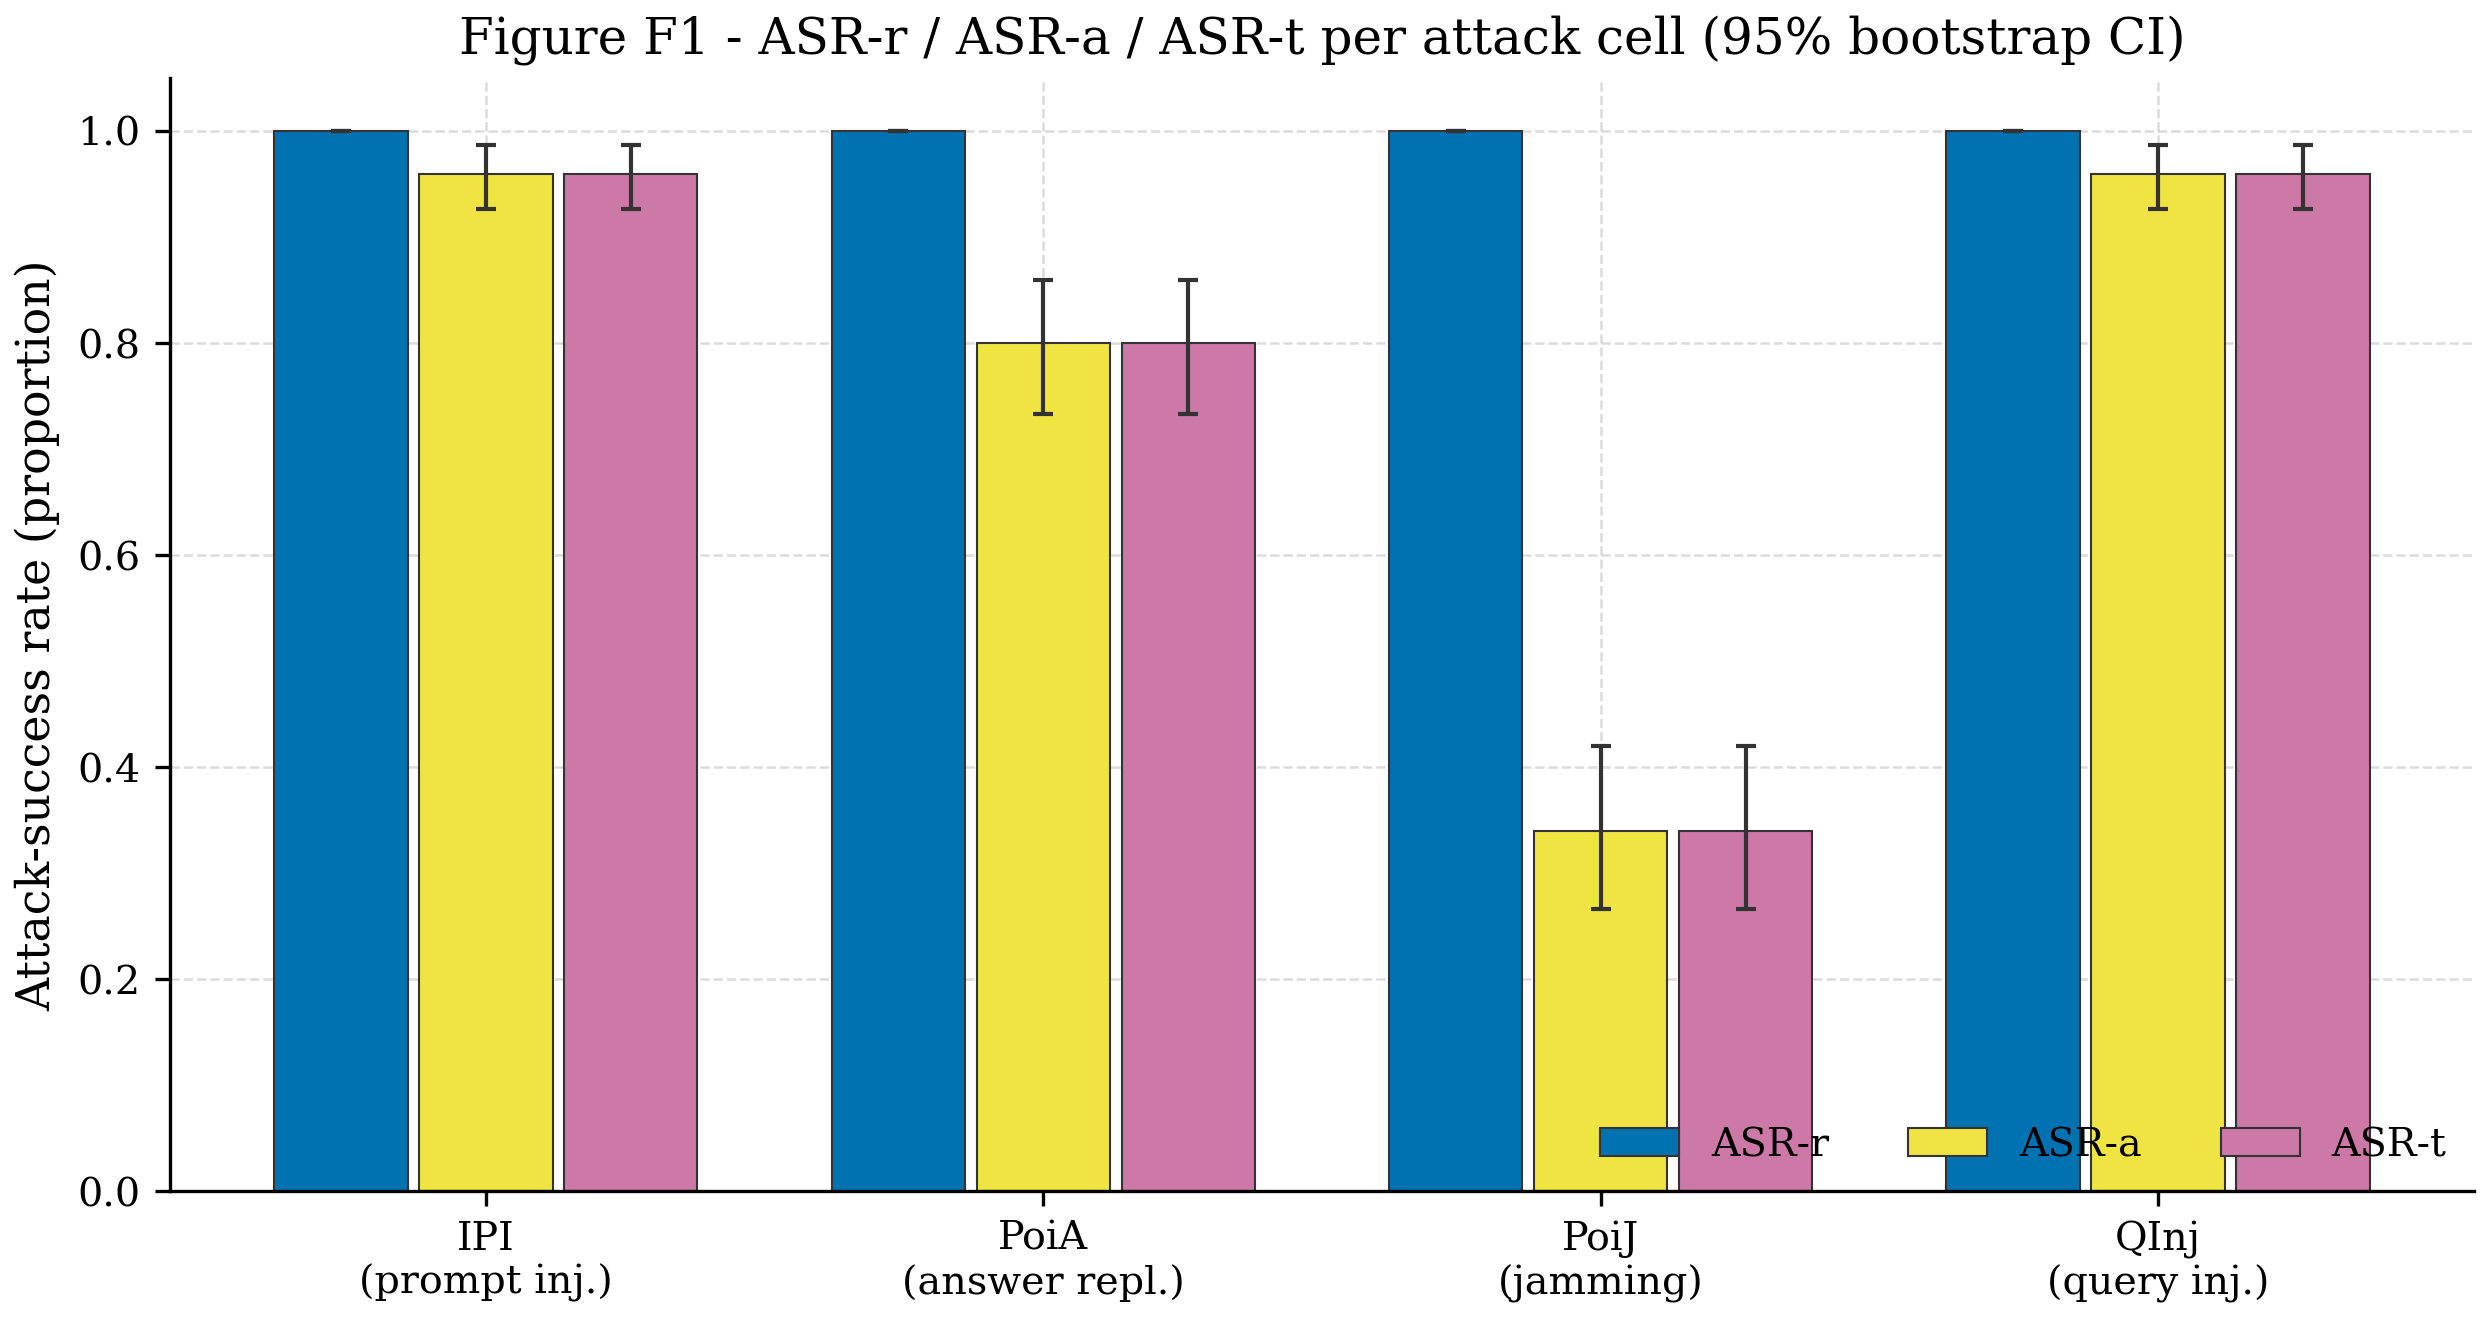

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\asr_triple_by_cell.pdf


In [6]:
path = plot_asr_triple_by_cell(summary, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}")

**Reading F1.** ASR-r is 1.0 for every cell (the bar is full-height).
For the three corpus-channel cells this means the poisoned doc made it
into the top-5 retrieval on every (seed, query) trial; for `qInj` ASR-r
is trivially True. The drop from ASR-r to ASR-a/ASR-t indicates how
often the LLM resisted the attack: for IPI and QInj the LLM almost
always honoured the injection (96%), for PoiA the LLM caught and ignored
the false answer span on ~20% of trials, and for PoiJ ASR-t is 34% -
*not* an integrity success rate to celebrate but the slice of jamming
queries where the LLM happened to emit the attacker's target span
instead of refusing. F8 decomposes the poiJ bar into its three
operationally-distinct outcomes (refused / target hit / other answer).

## 4. Figure F2 - channel x objective heatmap

A 2x2 view of the framework's own taxonomy: rows are the adversarial
objective (integrity / availability), columns are the delivery channel
(corpus / query). Each tile reports the cell's headline success rate
with its 95% bootstrap CI. The empty quadrant (query-channel
availability) is not a missing experiment - it is the part of the
threat surface this framework deliberately does not cover, because no
query-channel attack in the framework targets availability.

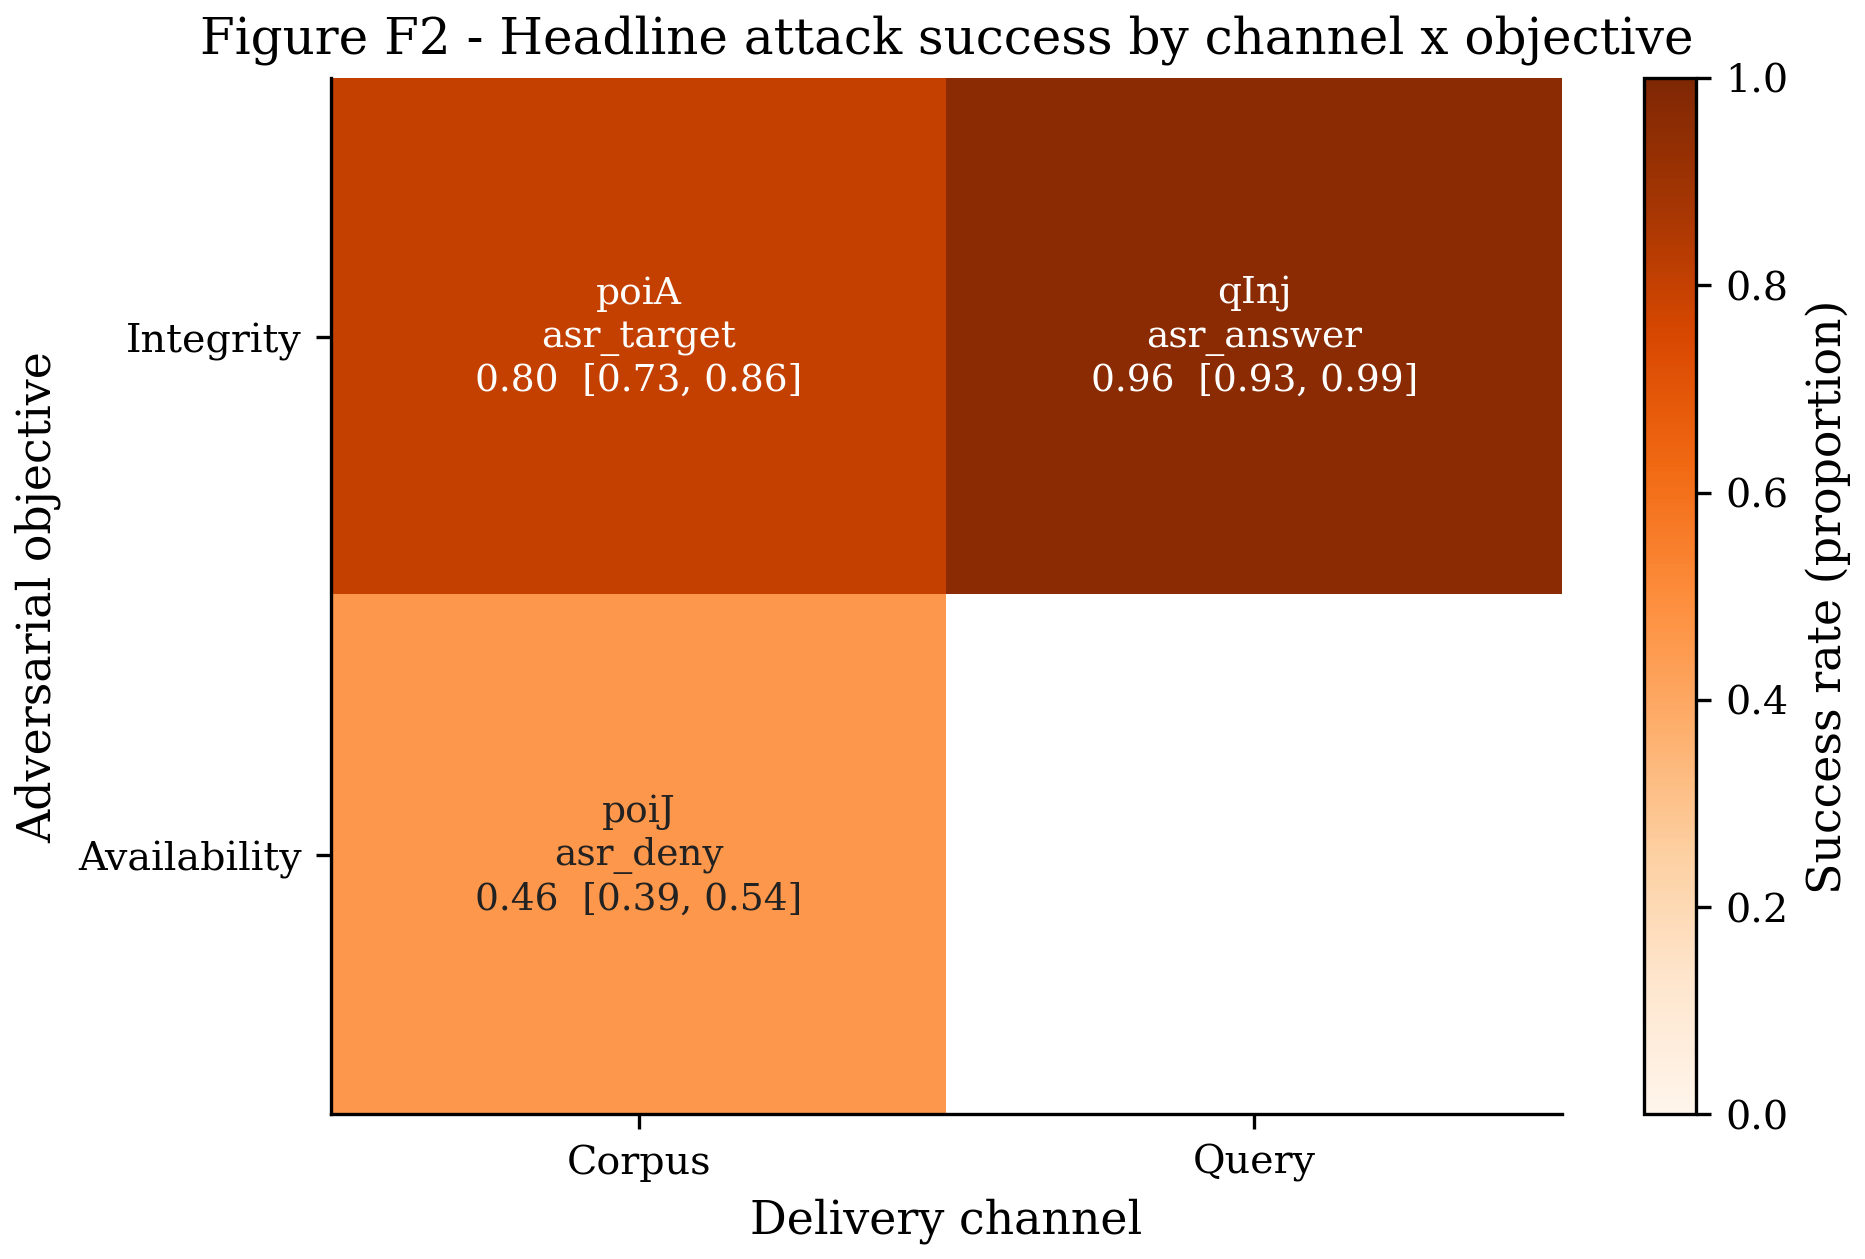

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\channel_objective_heatmap.pdf


In [7]:
path = plot_channel_objective_heatmap(summary, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}")

**Reading F2.** Integrity attacks are easy in both channels (0.80 and
0.96). The availability attack via the corpus is *hard* (0.00). The
asymmetry between the two integrity cells is the channel effect -
modifying the query gives the attacker the LLM's full attention in a
way that adding a competing corpus document does not.

## 5. Figure F3 - ASR-r vs retrieval depth k

Dose-response curve mirroring PoisonedRAG Fig.3. The x-axis is k
(retrieval depth, 1..5), the y-axis is ASR-r, one line per
corpus-channel cell. Shaded bands are 95% bootstrap CIs across the three
seeds. The query-injection cell is omitted by construction - it modifies
the query, not the corpus, so its ASR-r is True at every k.

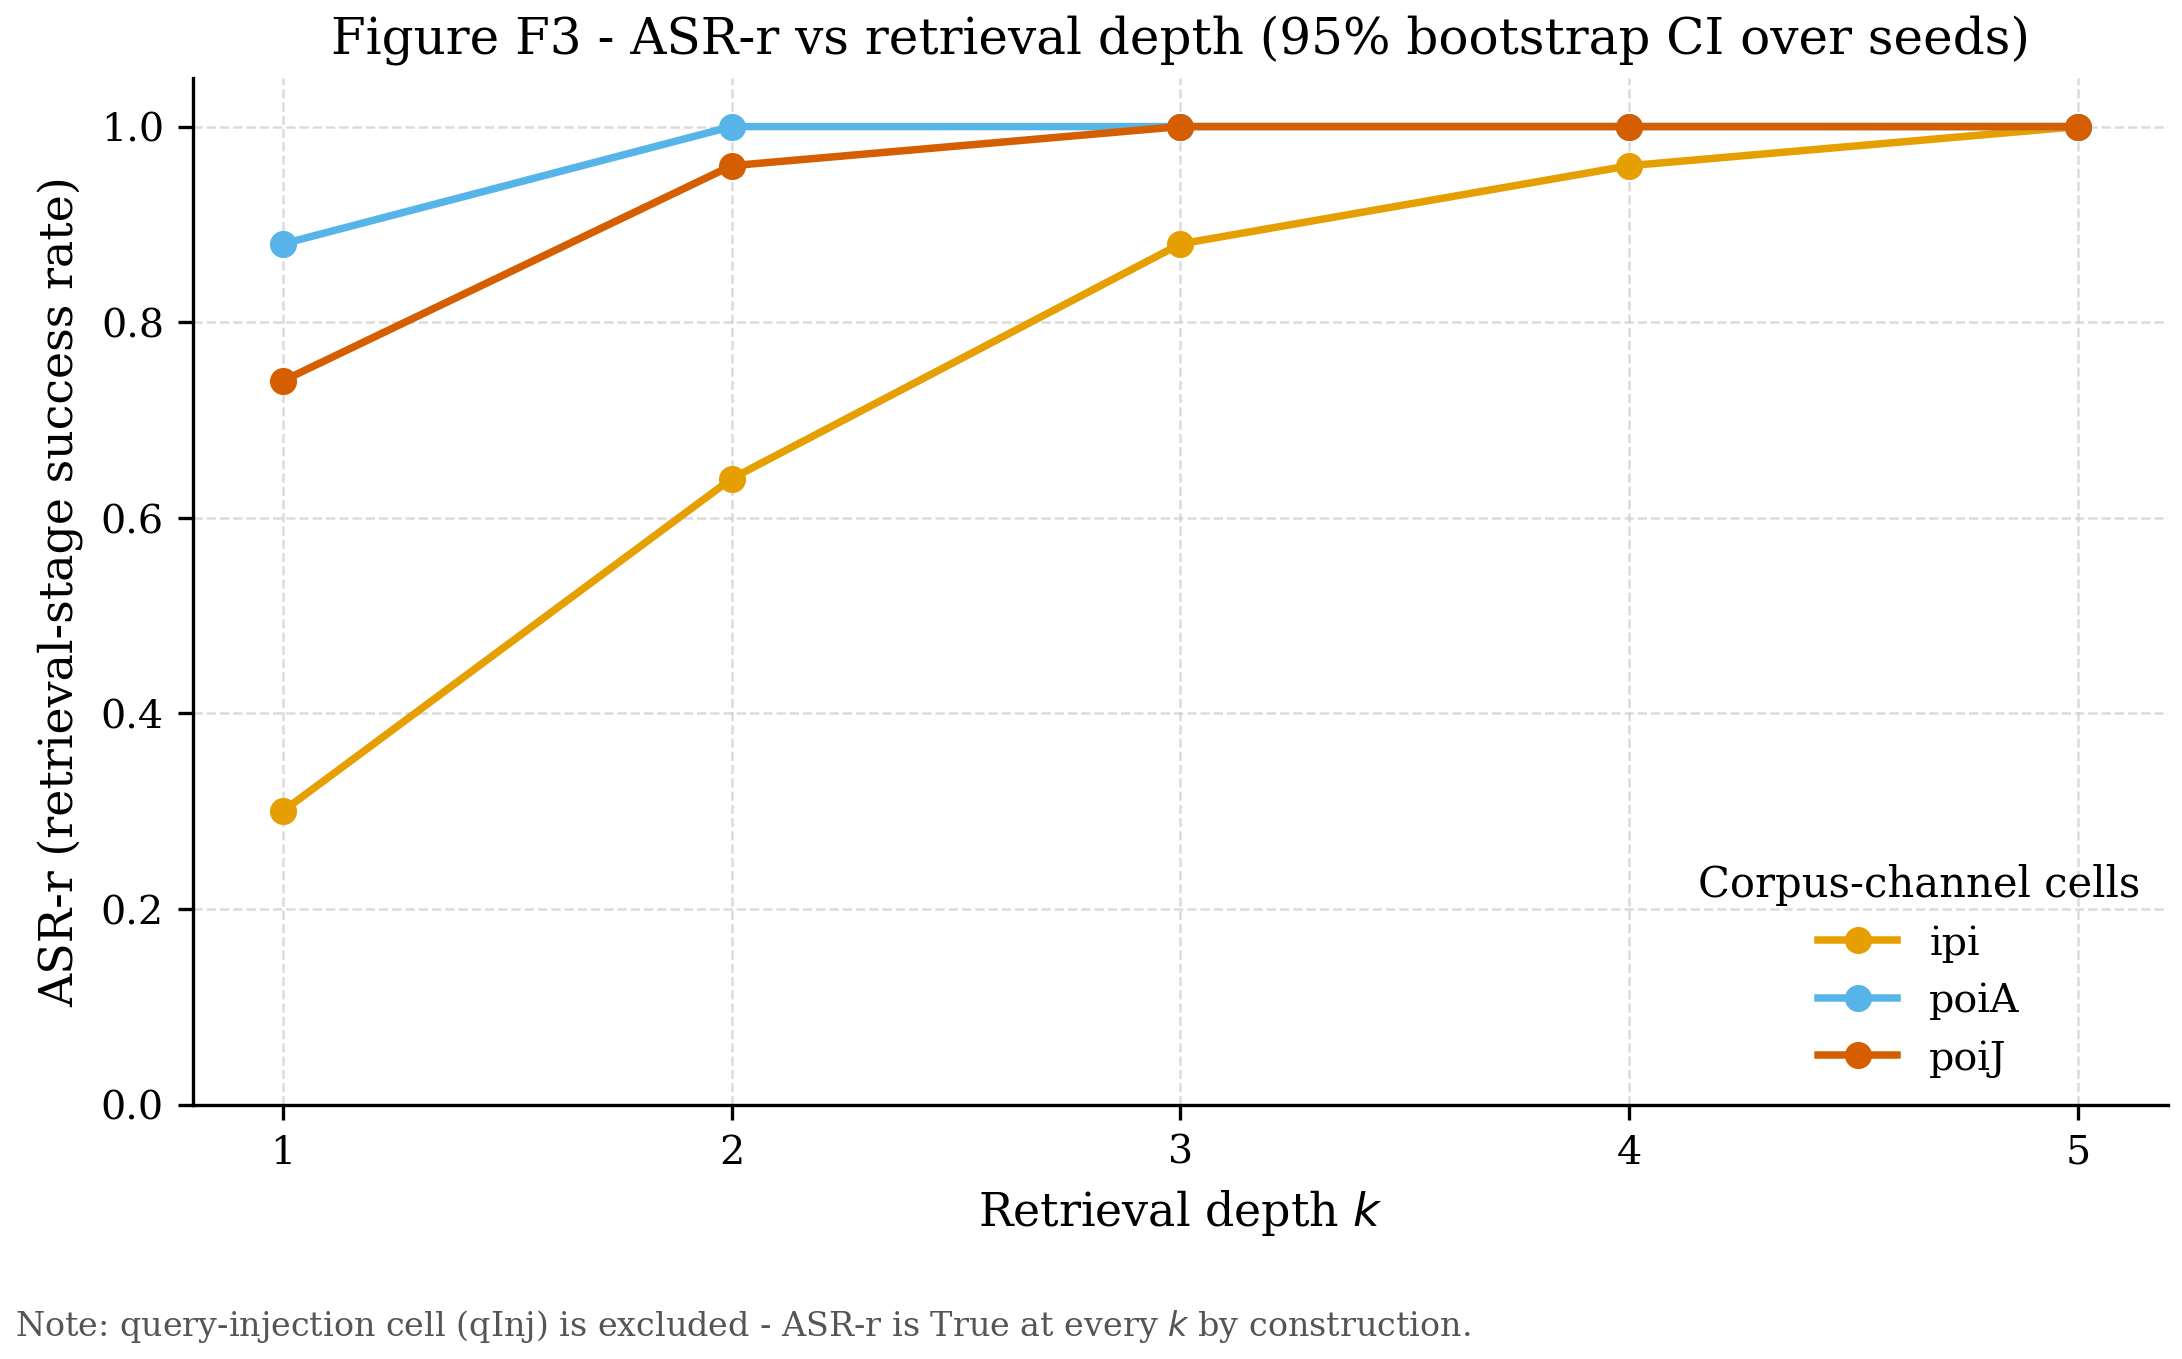

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\asr_r_vs_k.pdf  (per-rank rows: 2250)


In [8]:
bundles = load_bundles_for_k_curve(RUNS_DIR)
path = plot_asr_r_vs_k(bundles, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}  (per-rank rows: {len(bundles)})")

**Reading F3.** PoiA and PoiJ both reach ASR-r ~ 0.9 at k=1 - their
poisoned documents almost always land in rank-1 or rank-2 because the
exploit generator optimises the payload's surface similarity to the
query. IPI starts at 0.30 at k=1 and ramps to 1.0 by k=4: the injection
payload is a short imperative string that the retriever scores lower
than the original gold passage, so the poisoned doc more often appears
mid-rank. This is the dose-response interpretation - a defender who
truncates retrieval at k=1 cuts IPI's ASR-r in two-thirds, but pays
nothing against PoiA/PoiJ.

## 6. Figure F4 - ASR-deny per cell (availability headline)

The jamming cell's success metric is ASR-deny: did the LLM refuse or
otherwise punt on the answer? Post-Day-10 fix, the framework's
jamming attack lands roughly half the time (46%) - reported here as
the headline availability number alongside the three integrity cells
which sit at 0% as expected.

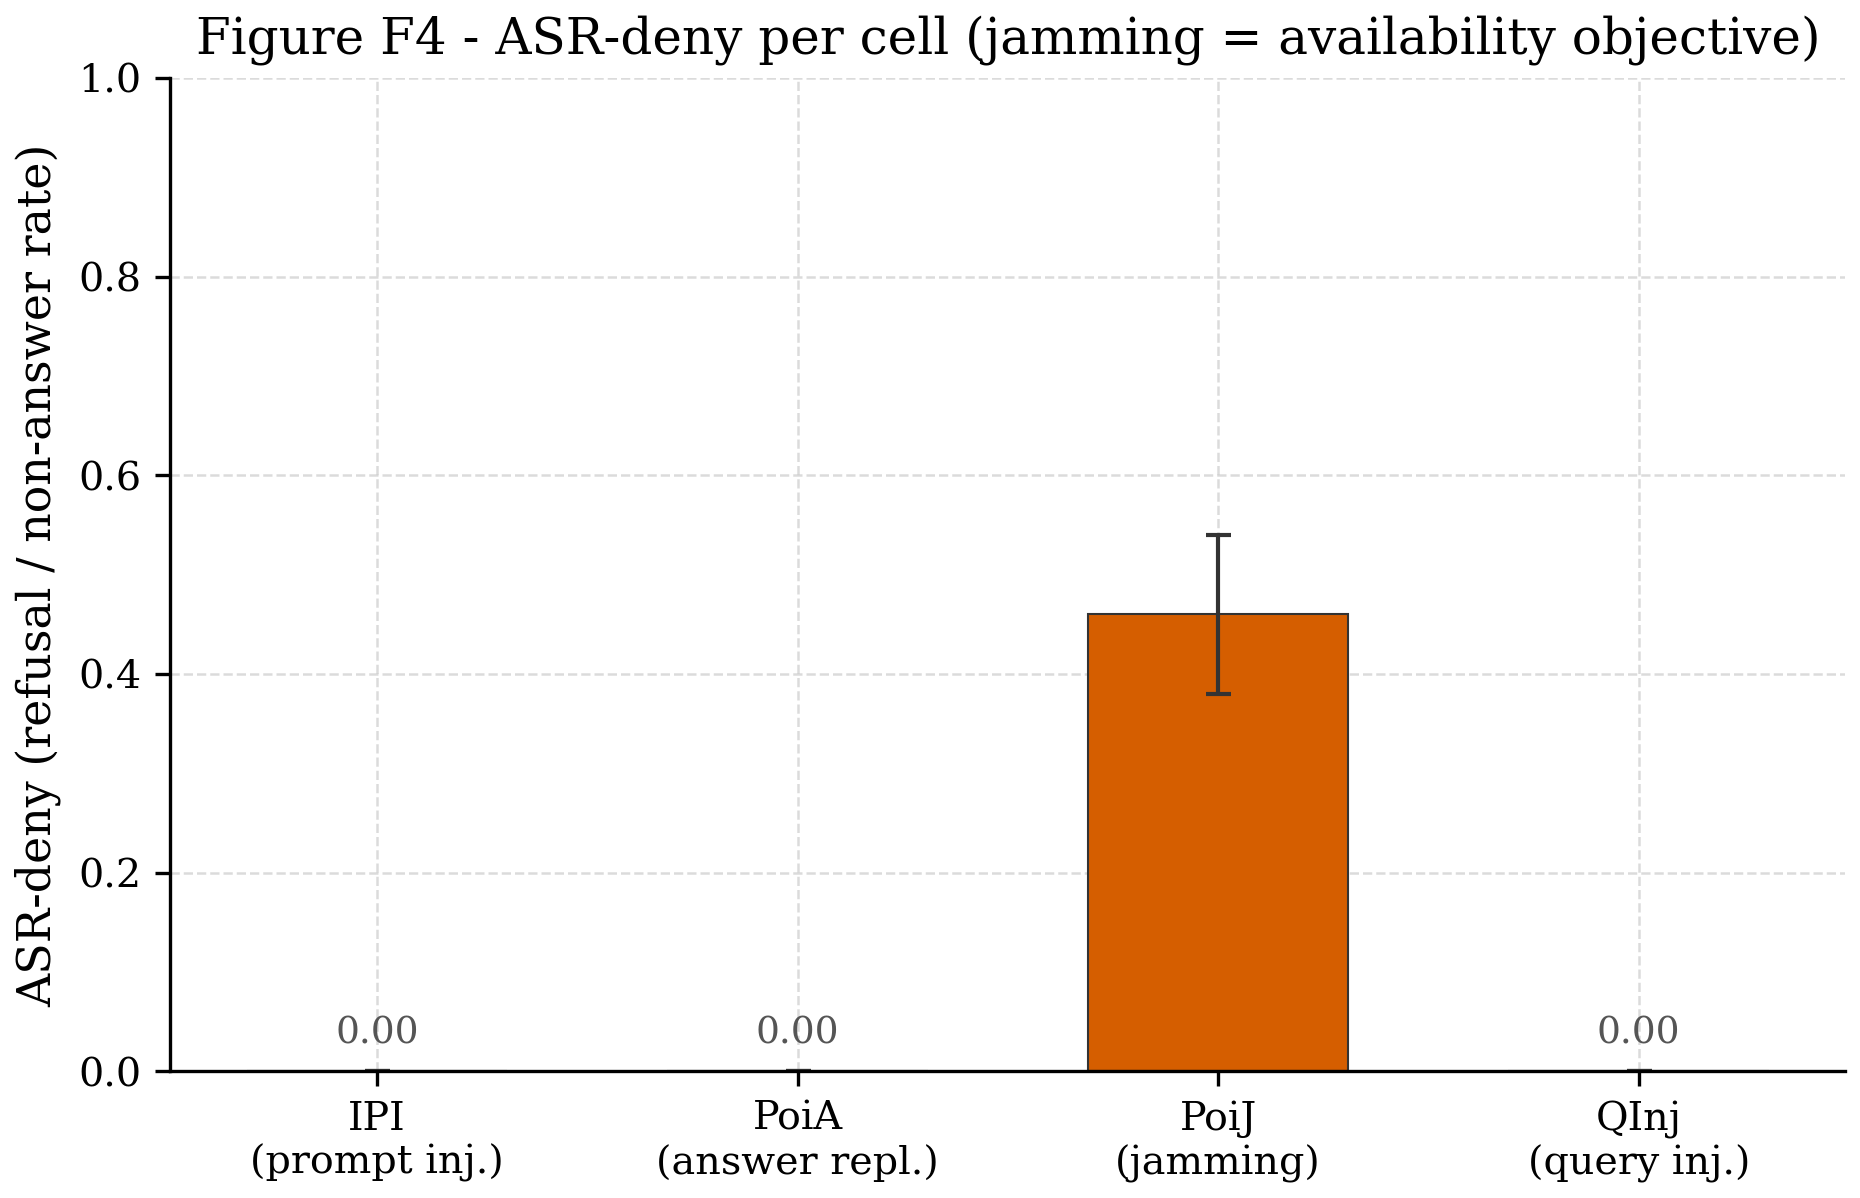

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\asr_deny_by_cell.pdf


In [9]:
path = plot_asr_deny_by_cell(summary, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}")

**Reading F4.** The poiJ bar reads ~46% with a tight bootstrap CI
[38.7, 54.0]; the three integrity cells sit at exactly 0% (they don't
aim to coerce refusal, and an integrity success doesn't accidentally
trigger a refusal prefix). The 46% is identical across all three seeds
(23/50 each) - the iter-0 jamming template payload is deterministic per
query, so the seed dimension contributes no extra variance for this
metric. F8 below breaks the poiJ bar into the four (asr_deny x
asr_target) outcomes; Chapter 7 discusses why the integrity collapse
(34% ASR-t) is best read as exploit-generator artefact rather than a
genuine integrity threat from the jamming payload.

## 6.5 Figure F8 - poiJ outcome decomposition

F4 reports the headline 46% ASR-deny but does not show what happened on
the other 54% of poiJ queries. F8 categorises every one of the 150 poiJ
runs by its (asr_deny, asr_target) pair into four mutually-exclusive
buckets so the full distribution of jamming outcomes is visible at a
glance.

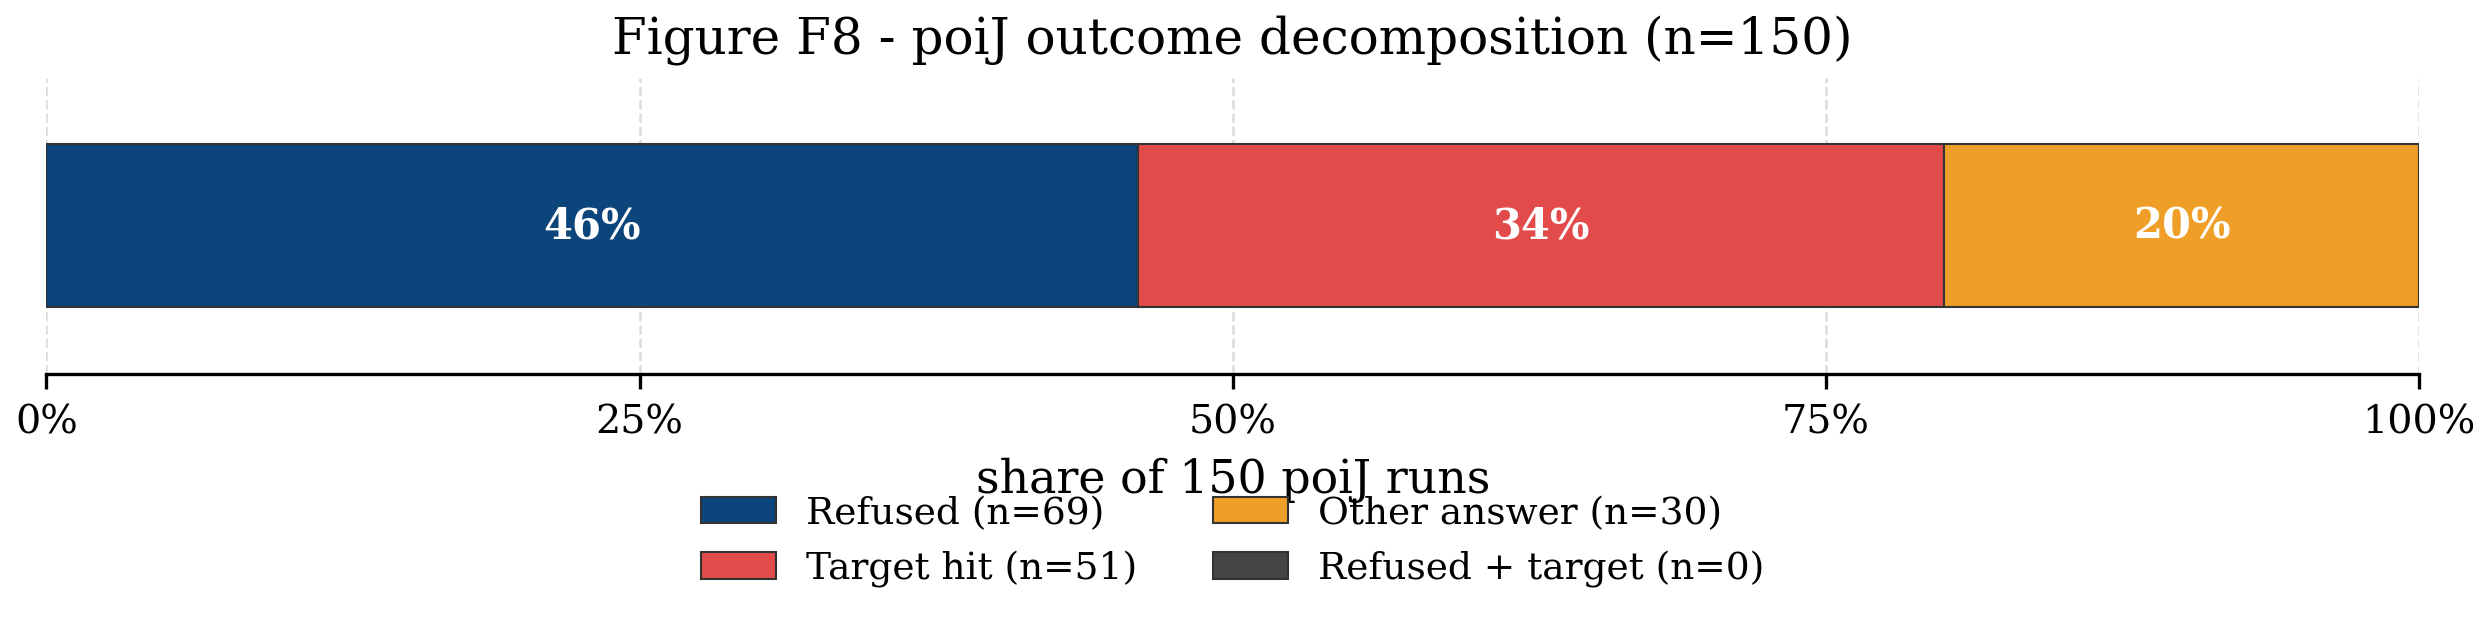

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\poij_outcome_decomposition.pdf


In [10]:
from redteam.analysis import plot_poij_outcome_decomposition
path = plot_poij_outcome_decomposition(data.runs, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}")

**Reading F8.** The four buckets sum to 100% of the 150 poiJ runs:
*refused* (asr_deny=True, asr_target=False) at 46% is the jamming win
- the iter-0 template coerced the LLM into one of the recognised
refusal prefixes; *target hit* (asr_deny=False, asr_target=True) at
34% is the collapsed-attack-mode artefact, where the LLM produced the
attacker's false answer rather than refusing; *other answer*
(asr_deny=False, asr_target=False) at 20% is a benign-looking response
the attacker did not control; and *refused + target* at 0% is the
structurally-impossible slot (a refusal prefix cannot contain the
target marker substring) drawn for completeness so a future regression
that produces an ambiguous outcome would surface visibly.

## 7. Figure F5 - RAGAS triple clean vs attacked

Three panels of split violins: Faithfulness, Answer Relevance, Context
Relevance. The grey violin is the clean baseline; the four coloured
violins are the four attacked cells. Each violin carries a black mean
dot with a 95% bootstrap-CI bar. The point of this figure is to make
visible the *decoupling* between ASR-t and Faithfulness in the PoiA
cell.

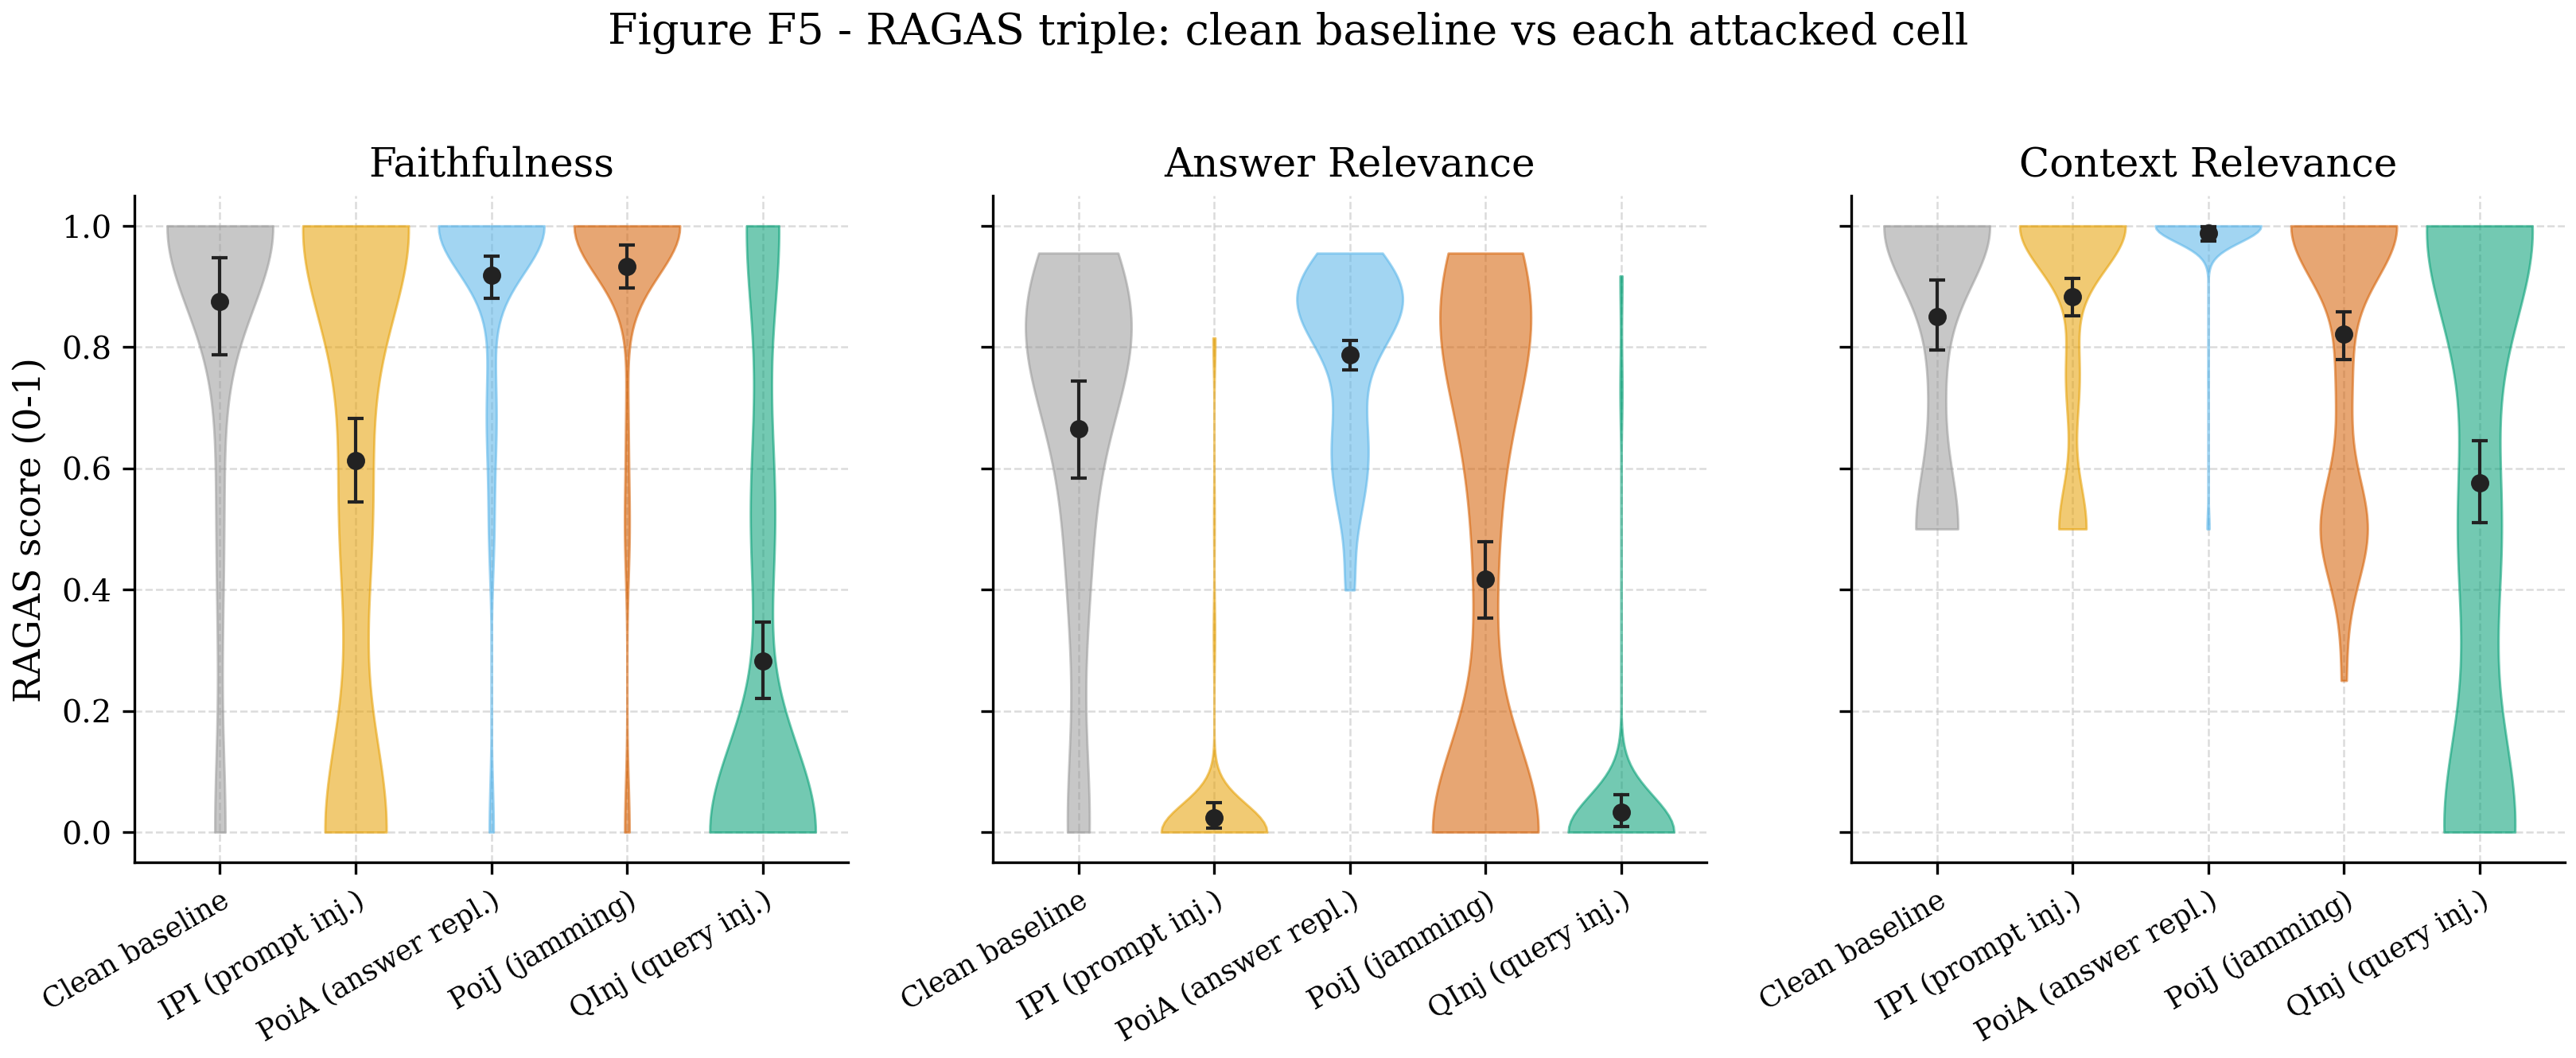

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\ragas_triple_clean_vs_attacked.pdf


In [11]:
path = plot_ragas_triple_violins(data.runs, baseline, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}")

**Reading F5.** Faithfulness panel: clean ~ 0.88, IPI ~ 0.61 (clear
drop), PoiA ~ 0.92 (*higher* than clean - poisoned context supports its
own false claim), PoiJ ~ 0.90, QInj ~ 0.28 (catastrophic drop). Answer
Relevance panel: clean ~ 0.67; IPI and QInj collapse to ~ 0.03 because
the injected answer is unrelated to the original query; PoiA/PoiJ keep
relevance high because their answer is still on-topic, just wrong.
Context Relevance: QInj's modified query no longer matches the
retrieved documents (clean ~ 0.85, attacked ~ 0.58); the other three
cells leave context relevance largely unchanged.

## 8. Figure F6 - rank_shift@5 distribution per cell

Empirical CDF of rank_shift@5 over 150 runs per cell, with a reference
line at zero. The y-axis is the cumulative fraction of runs whose
rank-shift is at most x. ECDFs preserve the tail in a way that means
and stacked bars do not - one in twenty runs with a large rank-shift is
invisible in a mean but obvious in the CDF.

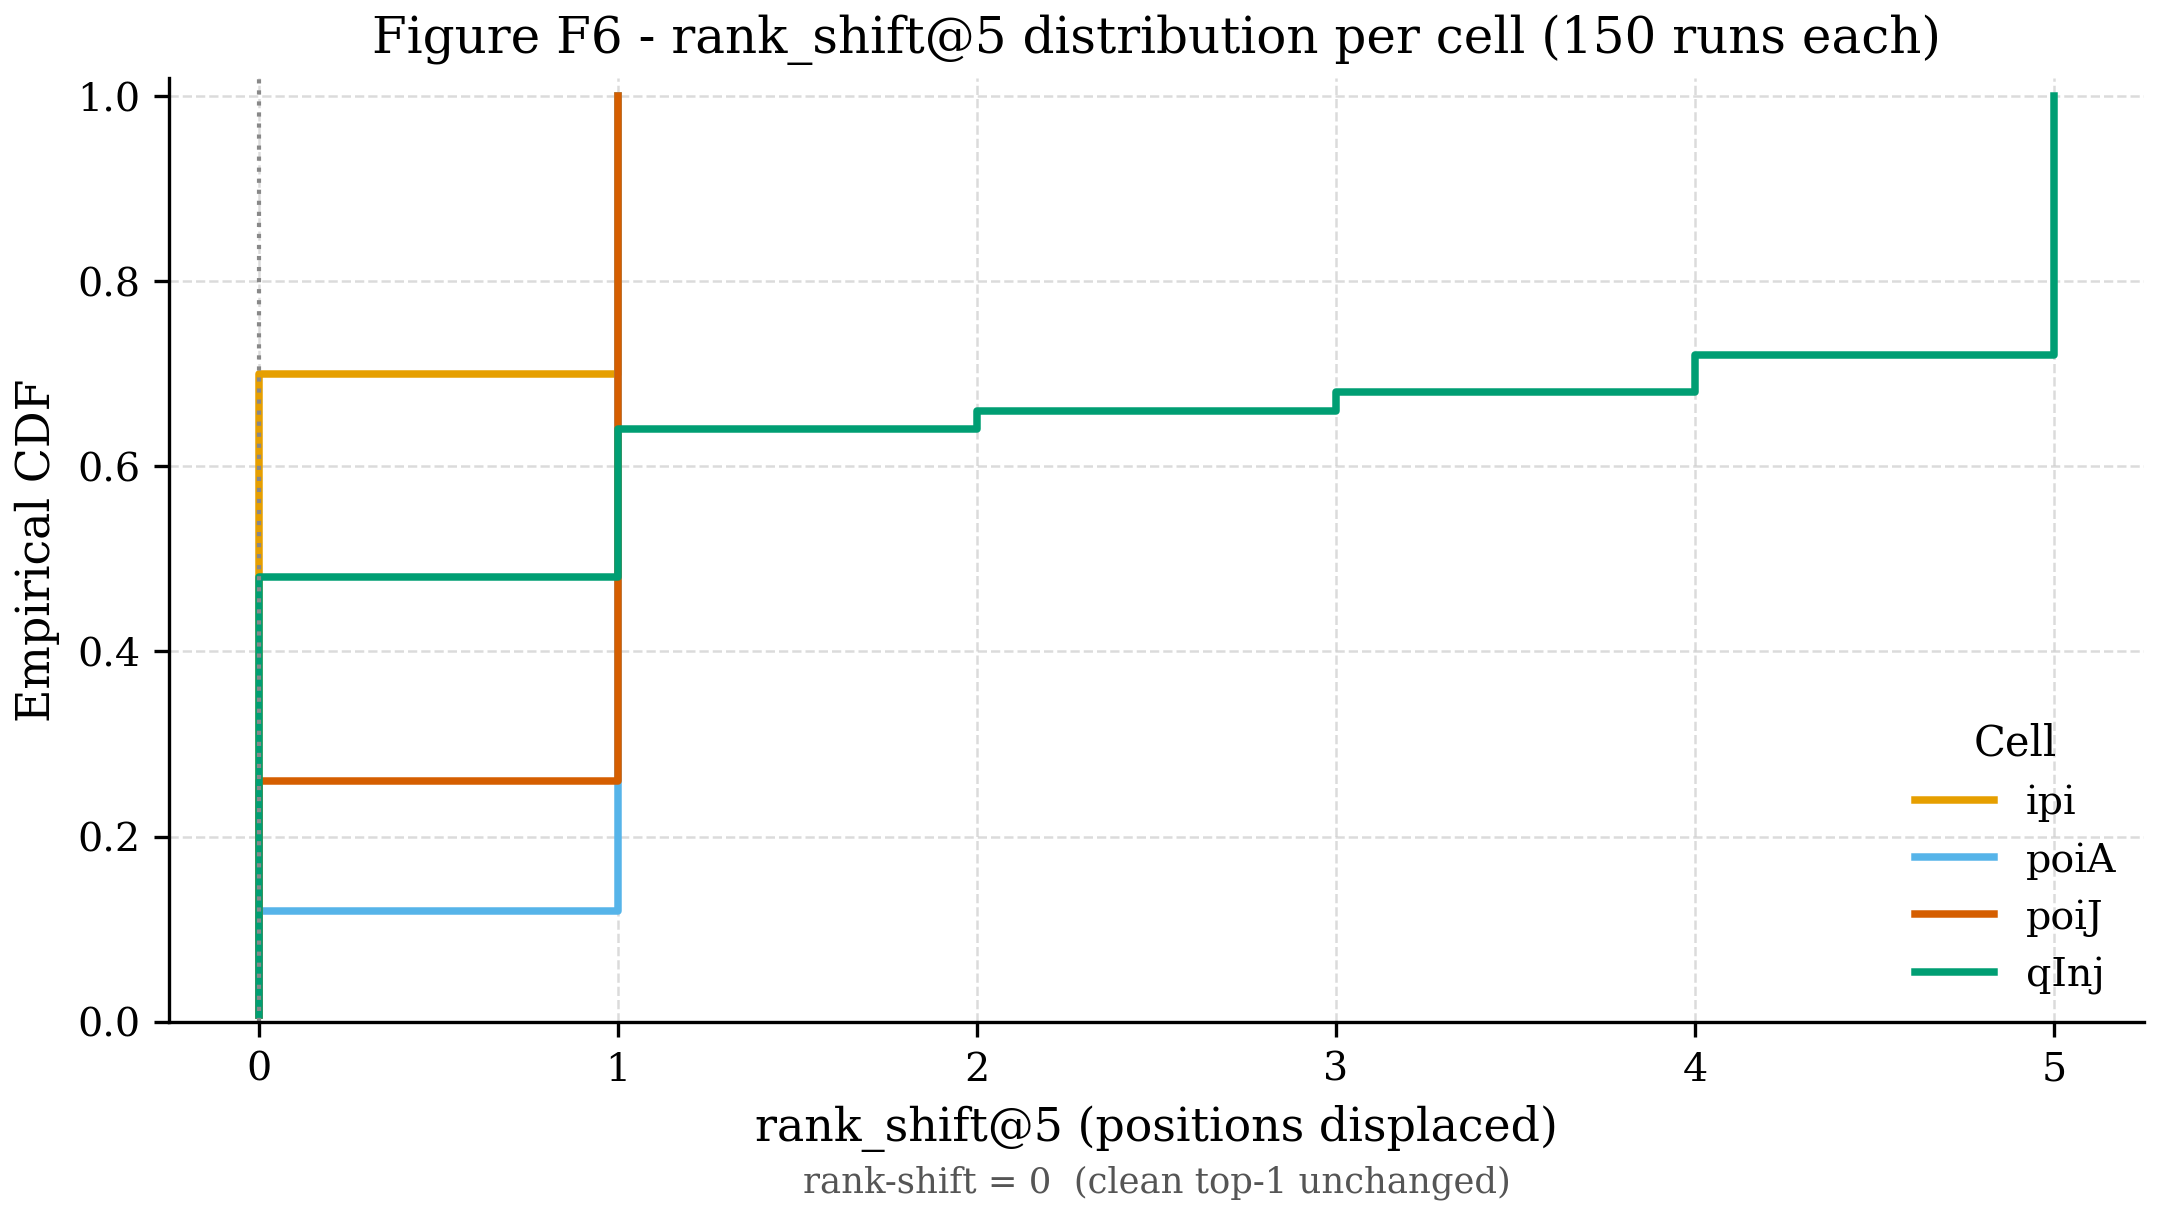

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\rank_shift_ecdf.pdf


In [12]:
path = plot_rank_shift_ecdf(data.runs, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}")

**Reading F6.** IPI and PoiJ have very tight rank-shift distributions
(over 90% of runs at shift <= 1). PoiA's curve is similar but with a
small tail at shift = 1 (poisoned doc pushed clean gold off the top
slot for that run). QInj has a much heavier tail extending to shift = 5
- the query-injection attack rewrites the query, so the retrieval's
gold-doc rank moves around much more.

## 9. Figure F7 - planner adaptation (epsilon-greedy convergence)

Left panel: running success rate per family vs query selection index,
averaged across the 3 seeds with shaded 95% bootstrap CIs. Right panel:
arm-pull histogram - how many times each family was selected, per seed.
This is the RQ2 figure: does the epsilon-greedy planner learn to
prefer the family with the higher success rate?

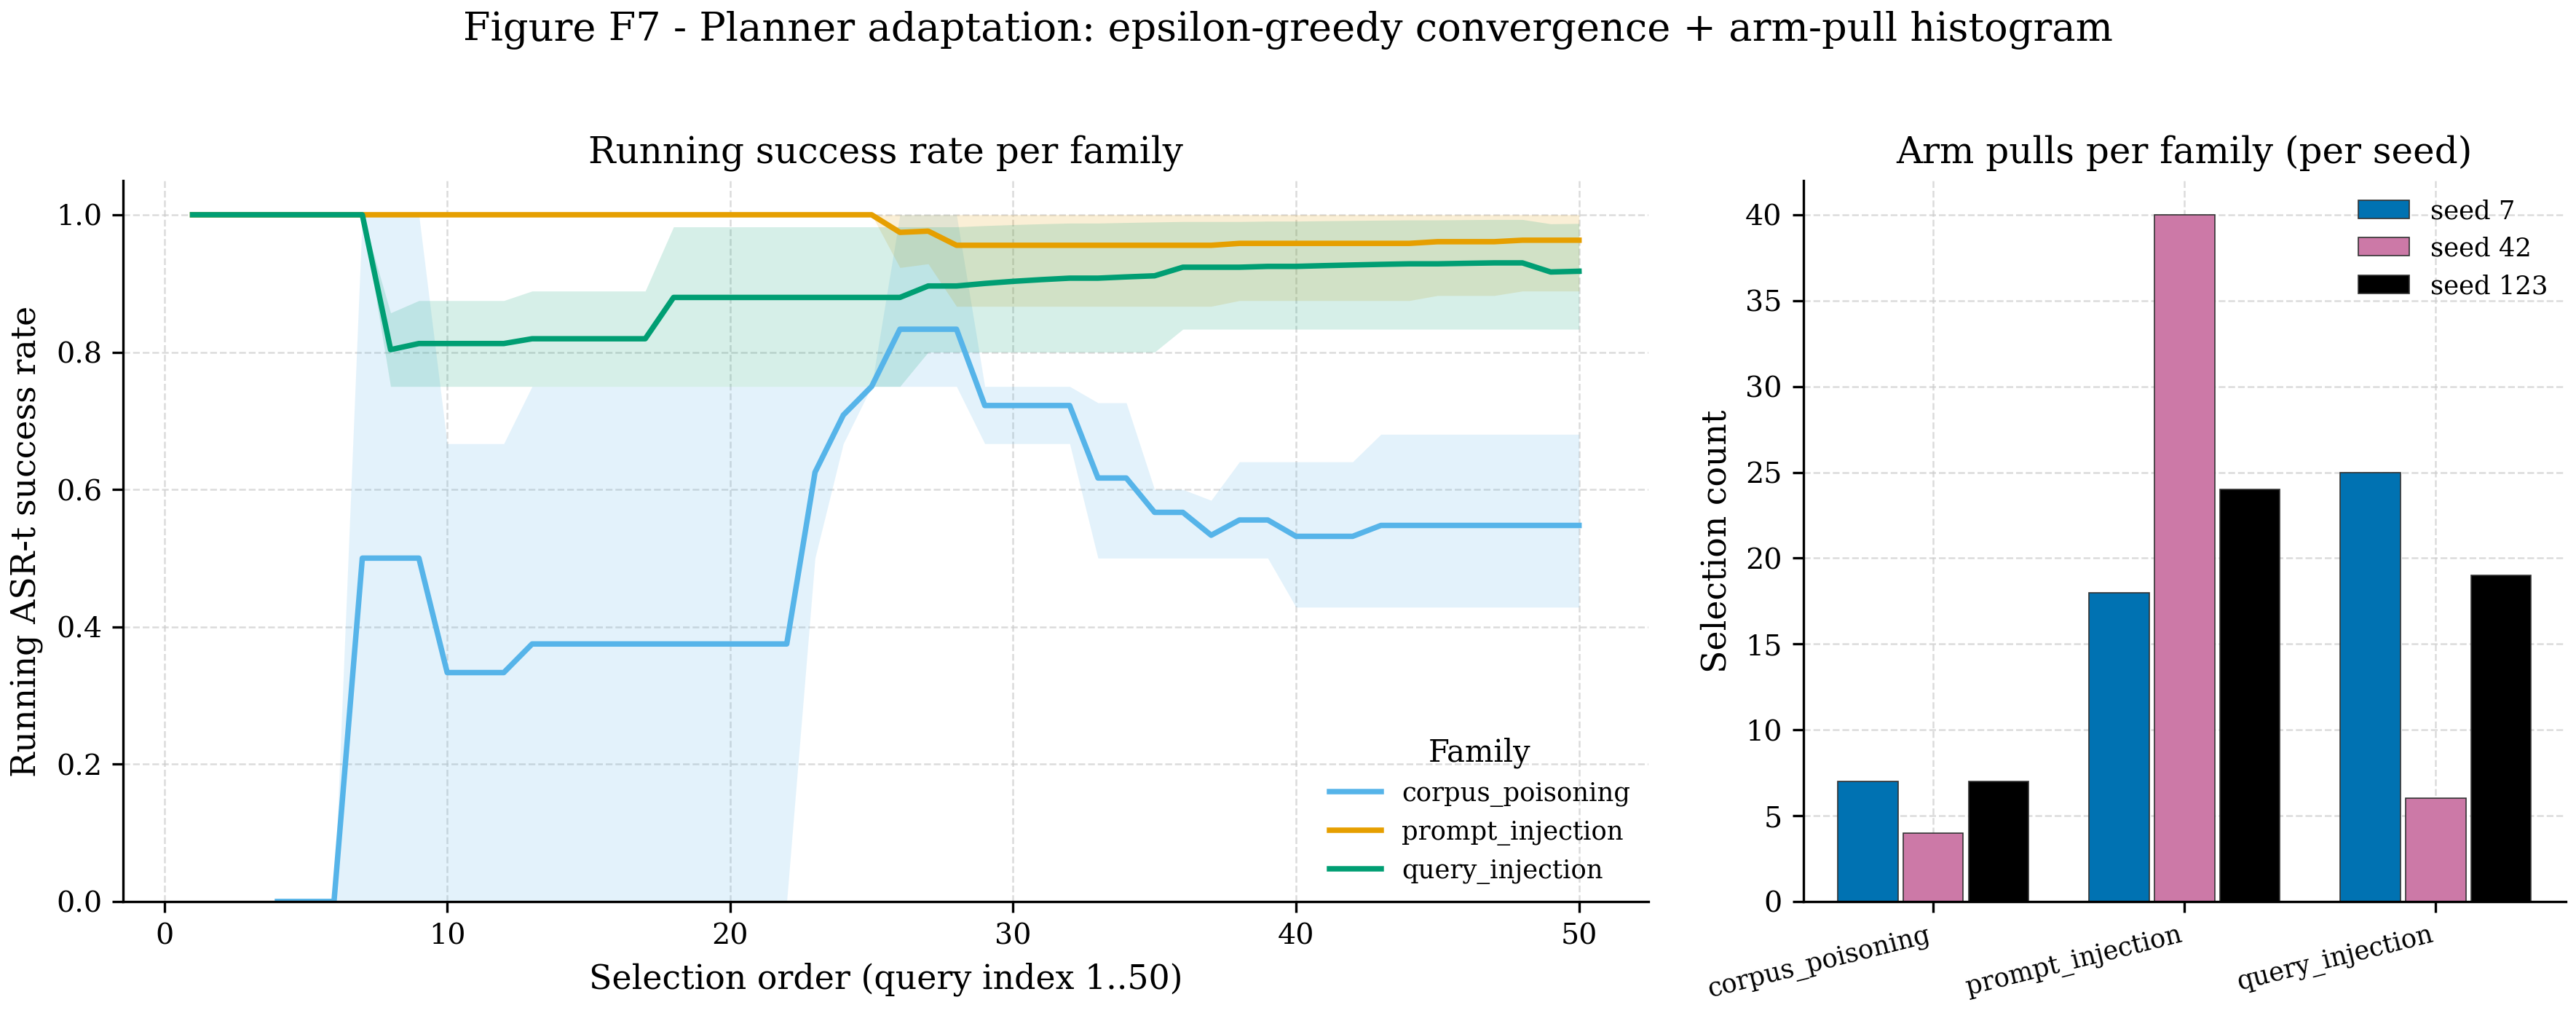

Saved: C:\Users\Emman\OneDrive\Documents\GitHub\agentic-red-team-framework\results\figures\planner_adaptation.pdf


In [13]:
path = plot_planner_adaptation(data.sidecars, FIGURES_DIR)
display(Image(str(path.with_suffix('.png'))))
print(f"Saved: {path}")

**Reading F7.** Prompt-injection and query-injection both converge to
~0.95 running success rate within 30 selections - the planner identifies
them as high-yield families early. Corpus-poisoning settles around 0.55
(reflecting that the family-default strategy in the sidecar is
`answer_replacement` which fails on ~20% of trials and is mapped to
`prompt_injection` in the per-cell taxonomy). The arm-pull histogram
shows the exploitation step is dominant - prompt-injection was selected
40 times in seed 42 - while exploration (corpus-poisoning at the bottom)
still gets a meaningful share via the epsilon=0.3 exploration rate.

## 10. Per-seed sanity check

A reproducibility evidence panel. The same per-cell story should appear
across all three seeds; large seed-to-seed swings would indicate
non-determinism leaking from somewhere we did not control. The
cross-tab below reports the per-(seed, cell) headline success counts
out of 50 queries.

In [14]:
crosstab = (
    data.runs
    .assign(success_int=lambda d: d["headline_success"].astype(int))
    .pivot_table(
        index="cell",
        columns="seed",
        values="success_int",
        aggfunc="sum",
    )
    .reindex(["ipi", "poiA", "poiJ", "qInj"])
)
crosstab["total"] = crosstab.sum(axis=1)
crosstab["n_per_seed"] = 50
display(crosstab)

seed,7,42,123,total,n_per_seed
cell,,,,,
ipi,48,48,48,144,50
poiA,40,40,40,120,50
poiJ,23,23,23,69,50
qInj,48,48,48,144,50


**Reading the cross-tab.** IPI and QInj are tight across seeds (~48/50
in each). PoiA varies a bit (39-42/50 depending on which queries the
exploit generator happened to produce a strong payload for; the
randomness is in the LLM exploit generator's temperature-0-but-not-
fully-deterministic sampling). **PoiJ is exactly 23/50 across every
seed** - the iter-0 template payload is the same per query regardless
of seed, so the headline (ASR-deny) is fully deterministic. Any
between-seed variance for PoiJ would show up only in iter-1+ runs the
fix now early-exits past.

## 11. Mapping to research questions

| RQ | Question | Primary evidence |
| --- | --- | --- |
| RQ1 | Do attacks succeed end-to-end against a black-box RAG? | F1, F2, summary_by_cell |
| RQ2 | Does the epsilon-greedy planner adapt to attack difficulty? | F7, sidecars |
| RQ3 | Where does the attack succeed or fail in the pipeline? | F1 (ASR-r vs ASR-a gap), F3 (retrieval-depth), F6 (rank-shift) |
| RQ4 | Does attack success correlate with measurable integrity loss? | F5, ragas_by_cell, paired_differences_vs_ipi |

The full Chapter 6 prose lives in `docs/RESULTS.md`. Every numeric claim
in that file references one of the CSVs the notebook just wrote.